In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df=pd.read_csv('Indian Liver Patient Dataset (ILPD).csv')

In [4]:
df.head()

,Age,Gender,Total Bilirubin,Direct Bilirubin,Alkanine Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albunin,Albumin and Globulin Ratio,"Liver Disease (yes:1, no:2)"
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [5]:
df.describe()

,Age,Total Bilirubin,Direct Bilirubin,Alkanine Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albunin,Albumin and Globulin Ratio,"Liver Disease (yes:1, no:2)"
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          583 non-null    int64  
 1   Gender                       583 non-null    object 
 2   Total Bilirubin              583 non-null    float64
 3   Direct Bilirubin             583 non-null    float64
 4   Alkanine Phosphotase         583 non-null    int64  
 5   Alamine Aminotransferase     583 non-null    int64  
 6   Aspartate Aminotransferase   583 non-null    int64  
 7   Total Proteins               583 non-null    float64
 8   Albunin                      583 non-null    float64
 9   Albumin and Globulin Ratio   579 non-null    float64
 10  Liver Disease (yes:1, no:2)  583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [56]:
#fixing null values in albumin and globulin ratio

from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='median')
df[['Albumin and Globulin Ratio']]=imputer.fit_transform(df[['Albumin and Globulin Ratio']])
df.isnull().sum()

Age                            0
Gender                         0
Total Bilirubin                0
Direct Bilirubin               0
Alkanine Phosphotase           0
Alamine Aminotransferase       0
Aspartate Aminotransferase     0
Total Proteins                 0
Albunin                        0
Albumin and Globulin Ratio     0
Liver Disease (yes:1, no:2)    0
dtype: int64

<Axes: xlabel='Total Bilirubin', ylabel='Direct Bilirubin'>

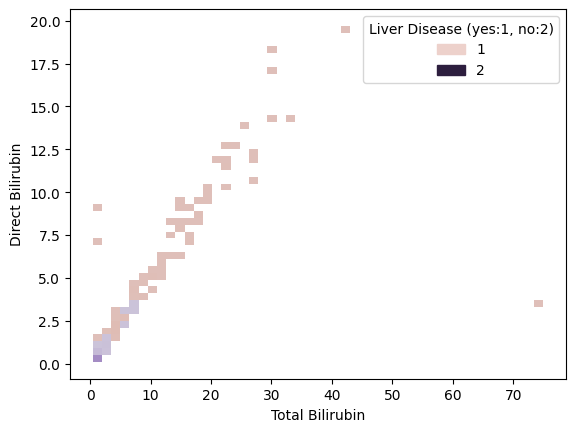

In [9]:
#relationship between total bilirubin and direct bilirubin
sns.histplot(x='Total Bilirubin',y='Direct Bilirubin',hue='Liver Disease (yes:1, no:2)',data=df)

In [10]:
df[['Total Bilirubin','Direct Bilirubin']].corr()

,Total Bilirubin,Direct Bilirubin
Total Bilirubin,1.000000,0.874618
Direct Bilirubin,0.874618,1.000000


In [11]:
# there is a strong correlation but not high enough to justify removing either of the columns

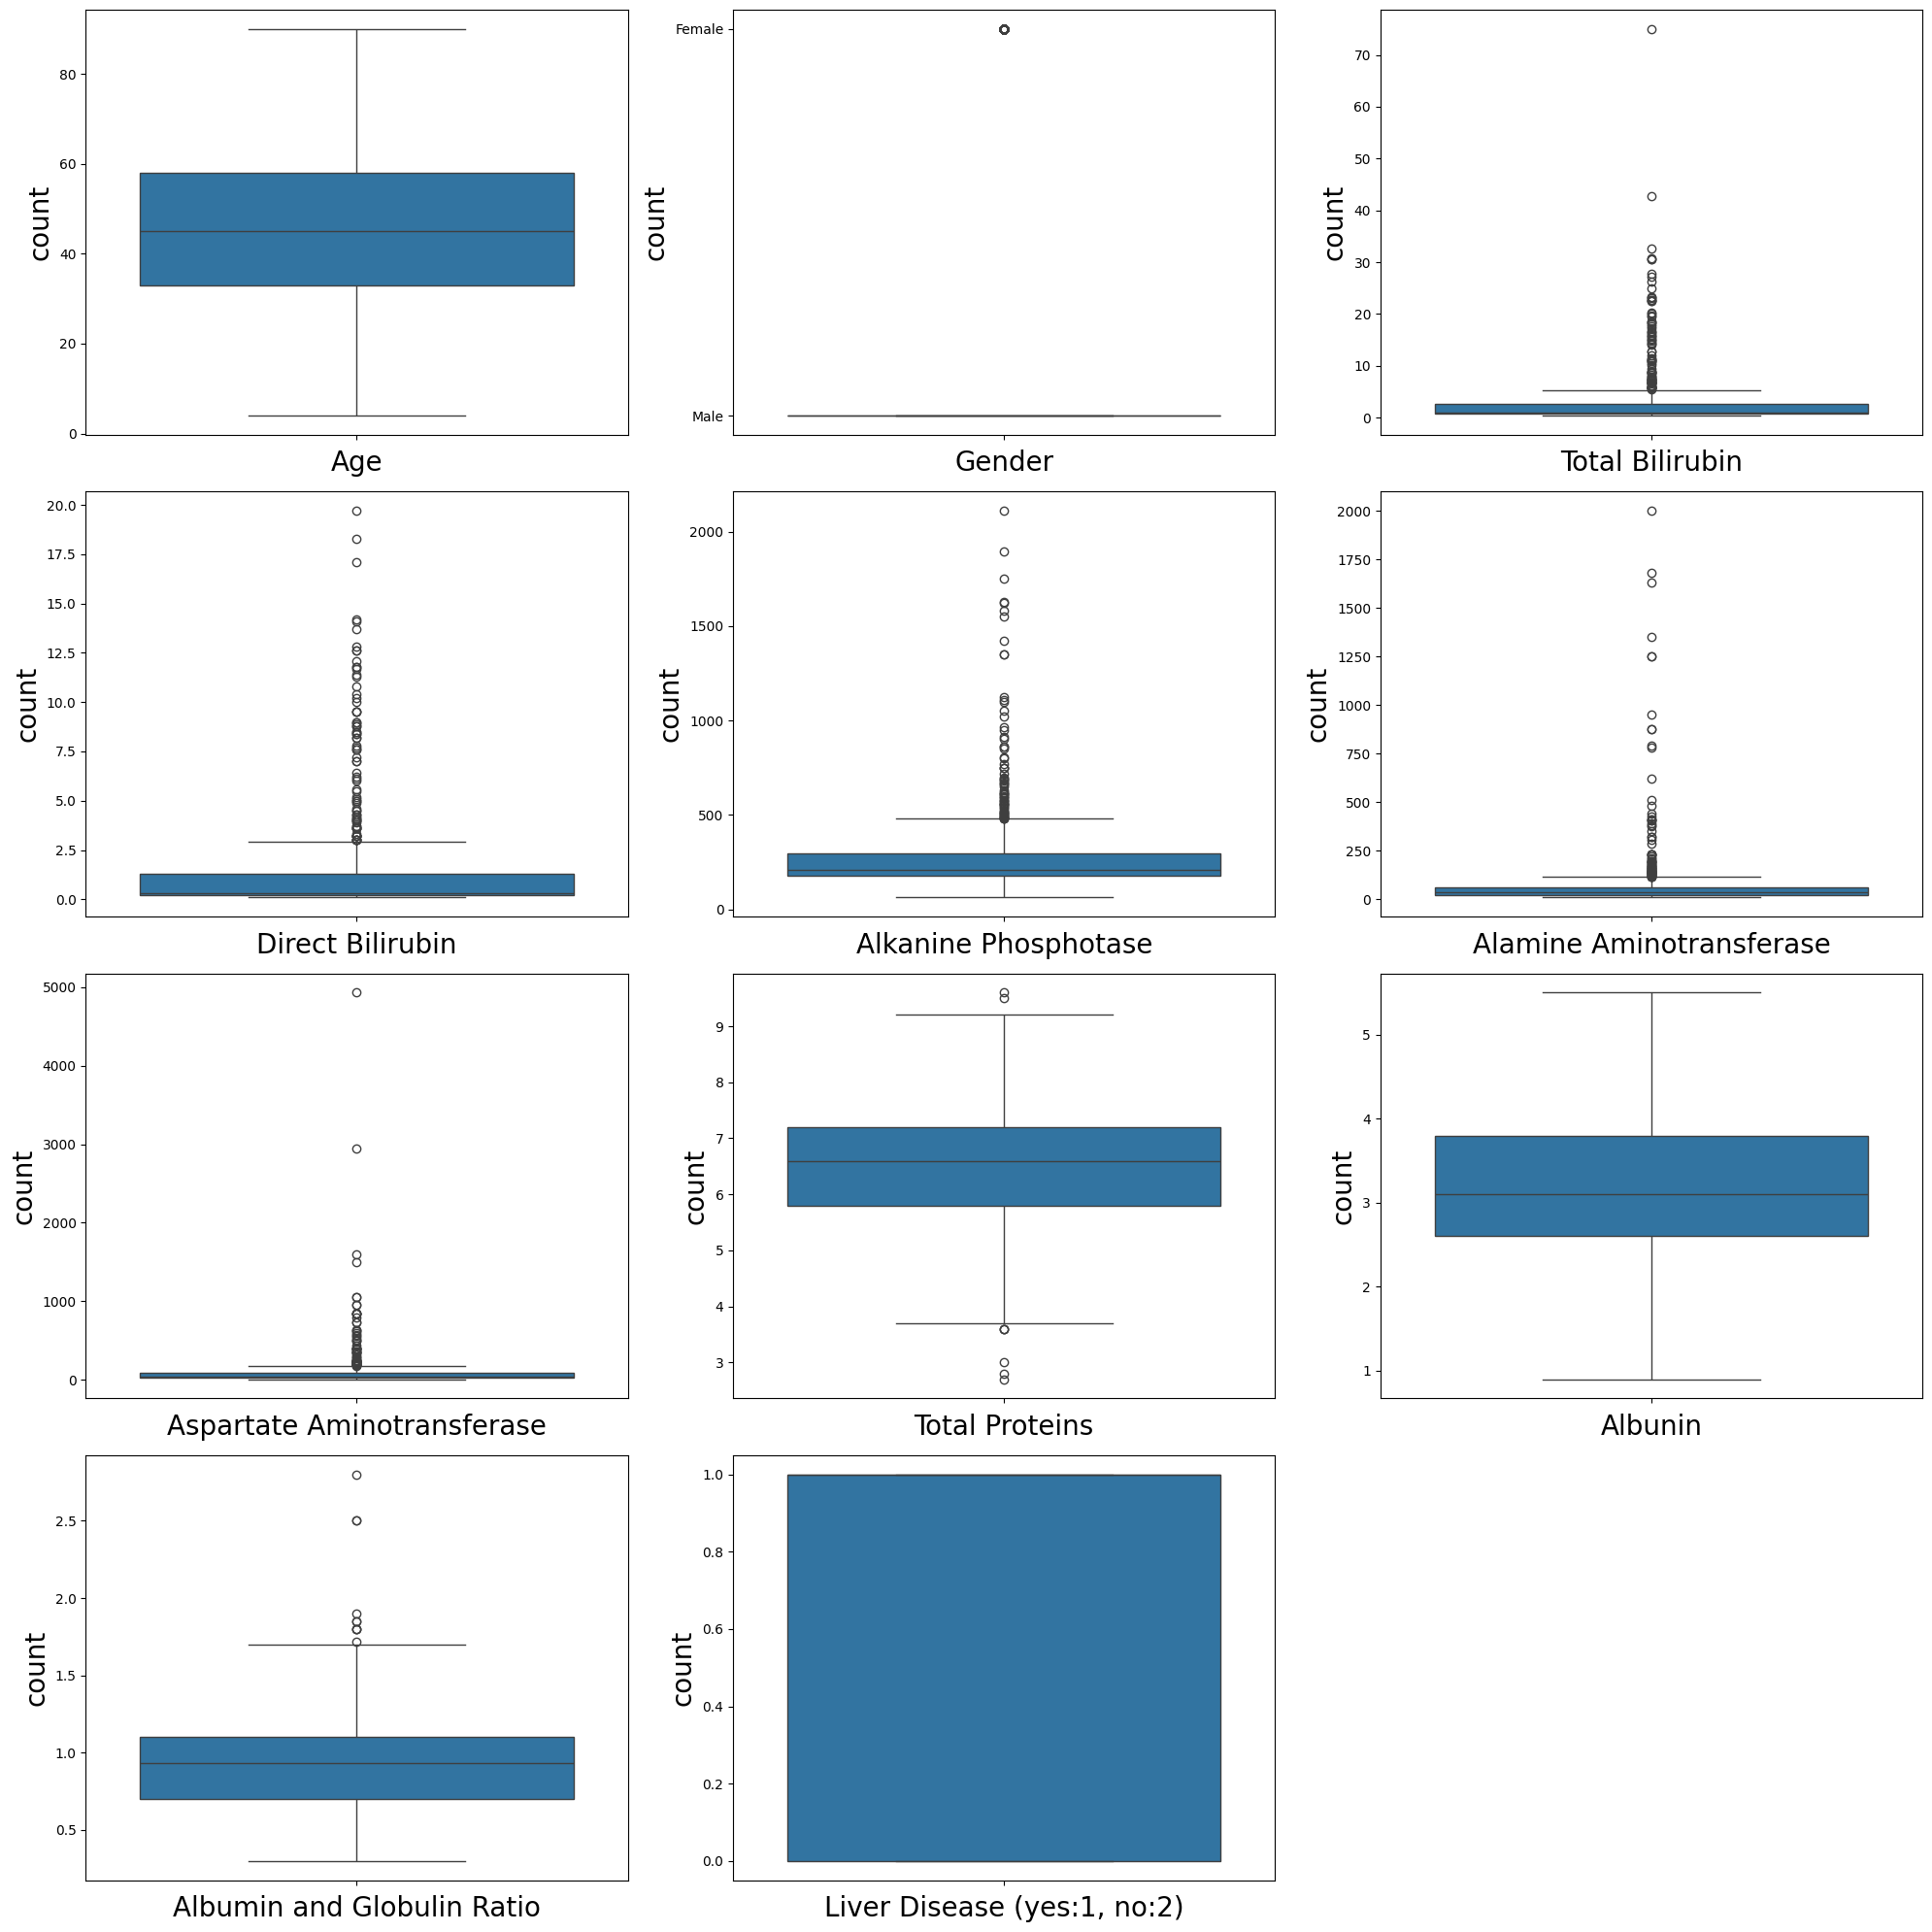

In [57]:
# checking outliers for all columns to determine the type of scaler to use

plt.figure(figsize=(20,20),facecolor='white')
plotnumber=1
for column in df:
    if plotnumber<12:
        ax=plt.subplot(4,3,plotnumber)
        sns.boxplot(df[column])
        plt.xlabel(column,fontsize=20)
        plt.ylabel('count',fontsize=20)
    plotnumber+=1
plt.tight_layout()

plt.show()

In [17]:
#extreme outliers = Total Bilirubin,Aspartate Aminotransferase,Alkanine Phosphotase,Direct Bilirubin,Albumin and Globulin Ratio

#normal outliers = age,total proteins,albunin

In [19]:
#remapping liver disease to 0 and 1 for model building
df['Liver Disease (yes:1, no:2)']=df['Liver Disease (yes:1, no:2)'].map({1:1,2:0})

In [58]:
df.describe()

,Age,Total Bilirubin,Direct Bilirubin,Alkanine Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albunin,Albumin and Globulin Ratio,"Liver Disease (yes:1, no:2)"
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947,0.713551
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000


In [81]:
#describing scalers to be applied by the pipeline
#using robust scaler for columns with extreme outliers, and standard scaler for columns with mild outliers

standard_scaler=['Age','Total Proteins','Albunin']
robust_scaler=['Total Bilirubin','Aspartate Aminotransferase','Alkanine Phosphotase','Direct Bilirubin','Albumin and Globulin Ratio']

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,RobustScaler



In [60]:
preprocessor=ColumnTransformer([
    ('OHE',OneHotEncoder(drop='first'),['Gender']),('standard_scaler',StandardScaler(),standard_scaler),('robust_scaler',RobustScaler(),robust_scaler)
])
preprocessor

,transformers,"[('OHE', ...), ('standard_scaler', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [61]:
#Logistic Regression 

X=df.drop(['Liver Disease (yes:1, no:2)'],axis=1)
y=df['Liver Disease (yes:1, no:2)']

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
pipeline_LR=Pipeline([('preprocessor',preprocessor),('model',LogisticRegression())])
pipeline_LR.fit(X_train,y_train)
y_pred_LR=pipeline_LR.predict(X_test)

In [62]:
#Decision Tree

from sklearn.tree import DecisionTreeClassifier
pipeline_DT=Pipeline([('preprocessor',preprocessor),('model',DecisionTreeClassifier())])
pipeline_DT.fit(X_train,y_train)
y_pred_DT=pipeline_DT.predict(X_test)

In [68]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier
pipeline_RF=Pipeline([('preprocessor',preprocessor),('model',RandomForestClassifier())])
pipeline_RF.fit(X_train,y_train)
y_pred_RF=pipeline_RF.predict(X_test)

In [71]:
#XG Boost

from xgboost import XGBClassifier
pipeline_XG=Pipeline([('preprocessor',preprocessor),('model',XGBClassifier())])
pipeline_XG.fit(X_train,y_train)
y_pred_XG=pipeline_XG.predict(X_test)

In [72]:
#SVM

from sklearn.svm import SVC
pipeline_SVM=Pipeline([('preprocessor',preprocessor),('model',SVC())])
pipeline_SVM.fit(X_train,y_train)
y_pred_SVM=pipeline_SVM.predict(X_test)

In [75]:
#model evaluation
#Model Comparison Report

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = pd.DataFrame({ "Model": ["Logistic Regression","Decision Tree","Random Forest","XGBoost","SVM"],"Accuracy":[accuracy_score(y_test, y_pred_LR),accuracy_score(y_test, y_pred_DT),accuracy_score(y_test, y_pred_RF),accuracy_score(y_test,y_pred_XG),accuracy_score(y_test,y_pred_SVM)], "Precision": [precision_score(y_test, y_pred_LR, average="weighted"),
precision_score(y_test, y_pred_DT, average="weighted"),precision_score(y_test, y_pred_RF, average="weighted"),precision_score(y_test, y_pred_XG, average="weighted"),precision_score(y_test,y_pred_SVM,average="weighted")],"Recall": [recall_score(y_test, y_pred_LR, average="weighted"),recall_score(y_test, y_pred_DT, average="weighted"),recall_score(y_test, y_pred_RF, average="weighted"),
recall_score(y_test, y_pred_XG, average="weighted"),precision_score(y_test,y_pred_SVM,average="weighted") ],"F1 Score": [f1_score(y_test, y_pred_LR, average="weighted"),f1_score(y_test, y_pred_DT, average="weighted"),
f1_score(y_test, y_pred_RF, average="weighted"),f1_score(y_test, y_pred_XG, average="weighted"),f1_score(y_test,y_pred_SVM,average="weighted")]})

results

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.720000,0.672968,0.720000,0.676939
1,Decision Tree,0.680000,0.720783,0.680000,0.693613
2,Random Forest,0.731429,0.710091,0.731429,0.716366
3,XGBoost,0.697143,0.683032,0.697143,0.688989
4,SVM,0.731429,0.534988,0.534988,0.617973


In [76]:
#All models performed quite well but Random Forest consistently delivered higher scores across the board. 

In [80]:
#Create an analysis to show on what basis you have designed your model.  

### DataExploration - The excel files were missing the column names so I firstly updated the column names in the excel file. 
#most of the values were numeric which means we would need to scale them
#there were 4 missing values albunin and globumin ratio

###preprocessing - I imputed the missing values using simpleimputer because median works great in such scenarios. 
#I made boxplots to figure out the extreme values so that I can use robust scaler on them, and used standard scaler for the rest. 
#applied OHE for the gender column because they're not numeric nor are they ordinal
#replaced 1 and 2 values in target column with 0 and 1 so that our models can read them easily (especially XG Boost)

###model selection - I used all the relevant models to analyze the data to see which one comes out on top. Started from the basic LogisticRegression, used Decision based algorithsm and then also applied SVM
#Logistic Regression - It is the basis for binary classification data
#Decision Tree - It captures non-linear relationships between the data very well. 
#Random Forest - It provides great improvement speaking from performance standpoint. 
#XGB - Also a good gradient algorithm which is known for good performance.

###evaluation - Random Forest performed the best. I choose precission, recall and F1 score in addition to accuracy to see if there's any imbalances

In [79]:
#Report on challenges faced

#missing column names
##All the column names were missing in the xls file so I needed to manually input them in the file. 

#missing values in column Albunin and Globumin ratio
##there were 4 missing values that needed to be imputed using simpleimputer

#Target column had 1 and 2 instead of 0 and 1
##Target column 1 and 2 weren't ideal for certain models like XGB so I remapped them with 0 and 1. could have used LabelEncoder too but I thought this was much easier
